# Model Accuracy Checks

Some feature extraction/engineering for NLP tasks require accuracy checks since we use pre-trained models. The necessary accuracy checks are:

- The column `scene_note_inline` for scene location accuracy
- Sentiment mean VADER compound score
- Emotions scores for some main emotions
- Humor proportions

For the 1st item, we sample 5% (n=12) of the episodes and check how many scene changes there are per episode.

For the other 3 items, we can validate the first scene of each of these 12 episodes, since these are calculated per dialogue line and then averaged per episode.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, classification_report
import random

In [2]:
# script imports
df_script = pd.read_csv("preprocessed_data/df_script.csv")
df_emotion = pd.read_csv("dialogue_lines_results_data/df_dialogue_emotion.csv")
df_humor = pd.read_csv("dialogue_lines_results_data/df_dialogue_humor.csv")
df_sentiment = pd.read_csv("dialogue_lines_results_data/df_dialogue_sentiment.csv")

---
## Preprocessing for `scene_note_inline` for location

In [3]:
# list of episodes (generated in data_parser.ipynb)
lst = ['S06E06', 'S03E11', 'S08E11', 'S05E11', 'S04E10', 'S04E20', 'S06E07', 
       'S02E13', 'S09E19', 'S02E18', 'S02E23', 'S10E04']
lst

['S06E06',
 'S03E11',
 'S08E11',
 'S05E11',
 'S04E10',
 'S04E20',
 'S06E07',
 'S02E13',
 'S09E19',
 'S02E18',
 'S02E23',
 'S10E04']

In [4]:
matches = [
    (int(m.group(1)), int(m.group(2)))
    for n in lst
    if (m := re.search(r"S(\d{2})E(\d{2})", n))
]

matches

[(6, 6),
 (3, 11),
 (8, 11),
 (5, 11),
 (4, 10),
 (4, 20),
 (6, 7),
 (2, 13),
 (9, 19),
 (2, 18),
 (2, 23),
 (10, 4)]

In [5]:
# filter df_script to only these episodes
dfs = []

for n in matches:
    df_new = df_script[(df_script["season"] == n[0]) & (df_script["episode"] == n[1])]
    dfs.append(df_new)
    df_new = ""
    
df2 = pd.concat(dfs, ignore_index=True)

In [6]:
df2.shape

(3380, 11)

Now that the sample dataframe has been created, we can perform accuracy checks.

## `scene_note_inline` check

This requires watching the 12 listed episodes and counting the number of scene changes.

Location changes are marked. When the scene constantly switches between two locations, to show contrast or during a phone call, this counts as one location. When a scene continues in the same location as the previous scene (scene here meaning the predicted or derived value), it counts as one location change and not two.

In [7]:
# get number of scene cuts per episode
pattern4 = r"Scene[:,]? ((?:Mr\.|Mrs\.|Dr\.|Ms\. )?[^,.;]+)[.,;]?"
df2["scene_note_extracted"] = df2["scene_note_only"].str.extract(pattern4)[0]

scene_cuts = df2.groupby(["season", "episode"])["scene_note_extracted"].count().reset_index(name="predicted")
scene_cuts

,season,episode,predicted
0,2,13,14
1,2,18,15
2,2,23,14
3,3,11,14
4,4,10,16
5,4,20,13
6,5,11,11
7,6,6,14
8,6,7,15
9,8,11,14


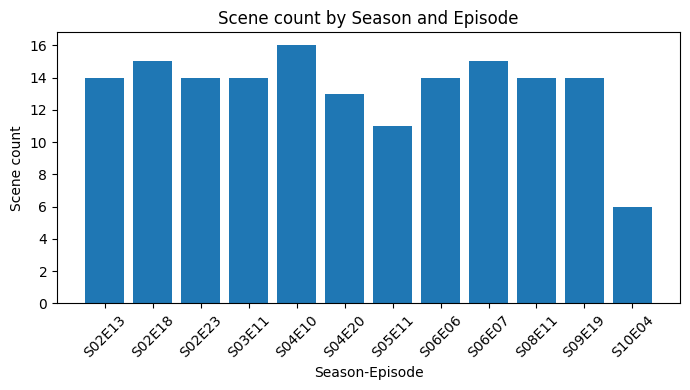

In [8]:
scene_cuts["label"] = scene_cuts.apply(lambda r: f"S{int(r.season):02d}E{int(r.episode):02d}", axis=1)

plt.figure(figsize=(7,4))
plt.bar(scene_cuts["label"], scene_cuts["predicted"])
plt.xticks(rotation=45)
plt.title("Scene count by Season and Episode")
plt.xlabel("Season-Episode")
plt.ylabel("Scene count")
plt.tight_layout()
plt.show();

In [9]:
# scene_cuts.drop(columns="label", inplace=True)

In [10]:
# manually added actual scene cuts
check_cuts = [14, 16, 14, 12, 15, 13, 10, 15, 14, 12, 12, 5]

if len(check_cuts) == 12:
    print("The accuracy can now be calculated.")

The accuracy can now be calculated.


In [11]:
# add column to "scene_cuts", call new column "actual"
scene_cuts["actual"] = check_cuts
scene_cuts

,season,episode,predicted,label,actual
0,2,13,14,S02E13,14
1,2,18,15,S02E18,16
2,2,23,14,S02E23,14
3,3,11,14,S03E11,12
4,4,10,16,S04E10,15
5,4,20,13,S04E20,13
6,5,11,11,S05E11,10
7,6,6,14,S06E06,15
8,6,7,15,S06E07,14
9,8,11,14,S08E11,12


In [12]:
scene_cuts['error'] = scene_cuts['predicted'] - scene_cuts['actual']
scene_cuts['abs_error'] = scene_cuts['error'].abs()

In [13]:
# MAE, MSE, RMSE, overestimations, correlation, accuracy, Cohen's Kappa
mae = scene_cuts['abs_error'].mean()
mse = (scene_cuts['error']**2).mean()
rmse = mse ** 0.5
bias = scene_cuts['error'].mean()
corr = scene_cuts['predicted'].corr(scene_cuts['actual'])
acc = accuracy_score(scene_cuts["actual"], scene_cuts["predicted"])
kappa = cohen_kappa_score(scene_cuts["actual"], scene_cuts["predicted"])

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Bias: {bias:.2f}")
print(f"Correlation: {corr:.2f}")
print(f"Accuracy: {acc:.2f}")
print(f"Cohen's Kappa: {kappa:.2f}")

MAE: 1.00
RMSE: 1.22
Bias: 0.67
Correlation: 0.93
Accuracy: 0.25
Cohen's Kappa: 0.10


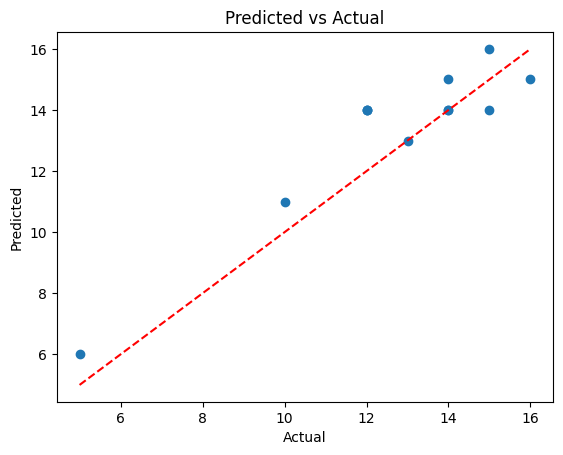

In [14]:
plt.scatter(scene_cuts['actual'], scene_cuts['predicted'])
plt.plot([scene_cuts['actual'].min(), scene_cuts['actual'].max()],
         [scene_cuts['actual'].min(), scene_cuts['actual'].max()],
         'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show();

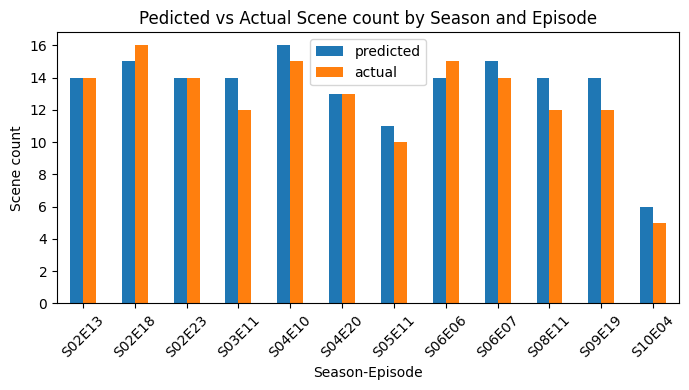

In [15]:
scene_cuts.plot(kind="bar", x="label", y=["predicted", "actual"], figsize=(7,4));

plt.xticks(rotation=45)
plt.title("Pedicted vs Actual Scene count by Season and Episode")
plt.xlabel("Season-Episode")
plt.ylabel("Scene count")
plt.tight_layout()
plt.show();

<div class="alert alert-block alert-info">
    The column has an error of MAE=1, usually <b>overestimating the number of scene location changes</b> by one or two scenes with a bias of 0.67. This is likely due to the characters remaining in the same location between scene cuts and commercial breaks, meaning there is no location change.
</div>

---
## Preprocessing for Humor, Emotion, and Sentiment

- `df_emotion` and `df_sentiment` both used "dialogue_raw" and hence includes stage directions
- `df_humor` used "dialogue_clean" with 33 "dialogue_raw" values where foreign language dialogue was not translated, something intelligible was said, or many people spoke over each other at the same time.

In [16]:
df_humor["humor"] = df_humor["humor"].astype(int)

First we get the random scenes per episode to check.

In [17]:
# random scene in each episode to check each line for each NLP feature model
check_sentiment = []
check_humor = []
check_emotion = []

check_list = [check_sentiment, check_humor, check_emotion]

random.seed(6)
for i in check_list:
    for n in check_cuts:
        k = random.randint(1, n)
        i.append(k)
    
print(check_sentiment)
print(check_humor)
print(check_emotion)

[13, 3, 8, 5, 1, 1, 3, 11, 10, 8, 12, 3]
[6, 1, 5, 8, 13, 4, 7, 15, 9, 9, 11, 1]
[4, 9, 11, 10, 11, 2, 7, 6, 2, 6, 7, 3]


For each of these episodes, the scene in `check_sentiment`, `check_emotion`, or `check_humor` will be analyzed. We will mark each line of dialogue in that scene in that episode according to the correct model.

In [18]:
# create dialogue df
df_dialogue = df_script[df_script["type"]=="dialogue"].copy()
df_dialogue.reset_index(inplace=True, drop=True)

In [19]:
# check that df_dialogue is the correct length
df_emotion.shape[0] == df_script[df_script["type"]=="dialogue"].shape[0]

True

In [20]:
# create check df
df_check = scene_cuts[["season", "episode", "actual"]].copy()
df_check["emotion"] = check_emotion
df_check["humor"] = check_humor
df_check["sentiment"] = check_sentiment
df_check

,season,episode,actual,emotion,humor,sentiment
0,2,13,14,4,6,13
1,2,18,16,9,1,3
2,2,23,14,11,5,8
3,3,11,12,10,8,5
4,4,10,15,11,13,1
5,4,20,13,2,4,1
6,5,11,10,7,7,3
7,6,6,15,6,15,11
8,6,7,14,2,9,10
9,8,11,12,6,9,8


---

We check for each model (`emotion`, `sentiment`, `humor`) the accuracy, precision, recall, etc, using `df_check`. If the randomly selected scene takes too long to watch or contains too much dialogue, we pick another random one.

## `df_emotion` check

For each relevant line, we will check whether the main emotion(s) is/are:
- anger
- digust
- fear
- sadness
- neutral
- surprise
- joy

In [21]:
# create emotion subset after manually finding the correct lines
emotion_subset = pd.concat([
    df_emotion.iloc[8821:8826], # S02E13, scene 4 - check
    df_emotion.iloc[10092:10101], # S02E18, scene 10 - check
    df_emotion.iloc[11501:11514], # S02E23, scene 11 - check
    df_emotion.iloc[14505:14527], # S03E11, scene 11 - check
    df_emotion.iloc[20614:20616], # S04E10, scene 10 - check
    df_emotion.iloc[23081:23118], # S04E20, scene 2 - check
    df_emotion.iloc[26927:26947], # S05E11, scene 6 - check
    df_emotion.iloc[31853:31861], # S06E06, scene 5 - check
    df_emotion.iloc[32071:32116], # S06E07, scene 2 - check
    df_emotion.iloc[46249:46269], # S08E11, scene 8 - check
    df_emotion.iloc[54443:54462], # S09E19, scene 7 - check
    df_emotion.iloc[56894:56914], # S10E04, scene 1 - check
])

In [22]:
# manually checked emotions for each lines in each chosen scene
emotion_list = ["neutral", "joy", "neutral", "disgust", "sadness",
               "surprise", "anger", "anger", "sadness", "surprise", "anger", "neutral", "disgust", "neutral",
                "joy", "neutral", "joy", "surprise", "neutral", "sadness", "neutral", "sadness", "neutral", 
                    "neutral", "neutral", "joy", "joy",
                "surprise", "joy", "surprise", "neutral", "joy", "neutral", "joy", "neutral", "joy", "joy", "joy", "neutral", 
                    "neutral", "surprise", "joy", "neutral", "joy", "joy", "surprise", "joy", "joy", "surprise",
                "neutral", "fear",
                "neutral", "neutral", "neutral", "surprise", "anger", "surprise", "neutral", "anger", "anger", "neutral", 
                    "anger", "neutral", "joy", "disgust", "neutral", "sadness", "neutral", "neutral", "neutral", "joy", 
                    "neutral", "sadness", "surprise", "neutral", "anger", "neutral", "surprise", "sadness", "neutral", 
                    "joy", "neutral", "joy", "neutral", "neutral", "anger", "neutral", "anger",
                "sadness", "sadness", "anger", "neutral", "surprise", "anger", "anger", "anger", "joy", "neutral",
                    "anger", "anger", "anger", "anger", "neutral", "anger", "joy", "neutral", "joy", "fear",
                "neutral", "sadness", "joy", "neutral", "surprise", "neutral", "neutral", "joy",
                "surprise", "neutral", "neutral", "joy",  "joy", "neutral", "surprise", "neutral",  "joy", "neutral", 
                    "surprise", "neutral", "joy", "neutral", "neutral", "surprise", "neutral", "neutral", "surprise", 
                    "neutral", "neutral", "surprise", "neutral", "joy", "neutral", "neutral", "neutral", "neutral", "joy", 
                    "surprise", "anger", "fear", "joy", "neutral", "neutral", "neutral", "sadness", "neutral", "joy", 
                    "neutral", "sadness", "neutral", "sadness", "neutral", "neutral",
                "surprise", "anger", "neutral", "anger", "joy", "neutral", "neutral", "neutral", "neutral", "neutral", 
                    "neutral", "neutral", "surprise", "joy", "anger", "neutral", "neutral", "neutral", "anger", "anger",
                "joy", "neutral", "neutral", "joy", "joy", "surprise", "neutral", "sadness", "disgust", "joy", "sadness", 
                    "neutral", "neutral", "anger", "joy", "joy", "joy", "anger", "sadness",
                "neutral", "neutral", "neutral", "joy", "anger", "anger", "neutral", "neutral", "anger", "anger", "neutral", 
                    "sadness", "neutral", "neutral", "anger", "disgust", "sadness", "sadness", "anger", "anger",
               ]

In [23]:
# check that each line has a value
emotion_subset.shape[0] == len(emotion_list)

True

## `df_humor` check

For each relevant line, we will check whether the spoken line itself is funny or not. This will be evaluated using the laughing cues within the show. If the laughing cue occurs due to the actions and not the spoken dialogue, the line does not count as funny.

In [24]:
# create humor subset
humor_subset = pd.concat([
    df_humor.iloc[8852:8865],  # S02E13, scene 6 - check
    df_humor.iloc[9980:9991],  # S02E18, scene 1 - check
    df_humor.iloc[11381:11394], # S02E23, scene 5 - check
    df_humor.iloc[14461:14474], # S03E11, scene 9 - check
    df_humor.iloc[20636:20645], # S04E10, scene 13 - check
    df_humor.iloc[23118:23153], # S04E20, scene 3 - check
    df_humor.iloc[26927:26947], # S05E11, scene 6 - check
    df_humor.iloc[32023:32034], # S06E06, scene 15 - check
    df_humor.iloc[32201:32217], # S06E07, scene 9 - check
    df_humor.iloc[46223:46237], # S08E11, scene 6 - check
    df_humor.iloc[54536:54563], # S09E19, scene 11  - check
    df_humor.iloc[56894:56914], # S10E04, scene 1  - check
])

In [25]:
# manually 0/1 for humor for each chosen scene's lines
humor_list = [0,0,0,1,0,0,1,0,1,0,0,0,1,
              0,0,0,0,0,0,0,0,0,1,1,
              0,0,0,0,0,1,1,1,1,1,1,1,1,
              0,1,0,1,0,1,1,0,1,0,0,0,0,
              1,1,1,1,0,1,0,0,1,
              0,0,0,0, 1,0,0,0, 0,0,0,0, 0,1,1,0, 1,0,1,0, 1,0,0,0, 1,0,0,0, 1,0,1,0, 1,0,1,
              0,0,0,0,1,0,0,1,1,1,1,0,1,1,1,1,0,1,0,1,
              0,0,0,1,0,0,1,1,0,0,1,
              0,0,0,0,0,1,0,0,0,0,1,0,1,1,1,1,
              0,0,1,0,0,1,0,1,0,1,1,1,1,1,
              0,0,1,1,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1,1,
              0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,
             ]

In [26]:
# check that each line has a value
humor_subset.shape[0] == len(humor_list)

True

## `df_sentiment` check

For each relevant line, we will check what the sentiment of the line is: positive, neutral, or negative. This is also aprtially dependent on the character's tone for the line.

In [27]:
# create sentiment subset
sentiment_subset = pd.concat([
    df_sentiment.iloc[8961:8966],  # S02E13, scene 13 - check
    df_sentiment.iloc[10013:10030],  # S02E18, scene 3 - check
    df_sentiment.iloc[11435:11464],  # S02E23, scene 8 - check
    df_sentiment.iloc[14417:14422],  # S03E11, scene 6 - check
    df_sentiment.iloc[20429:20444],  # S04E10, scene 1 - check
    df_sentiment.iloc[23078:23081],  # S04E20, scene 1 - check
    df_sentiment.iloc[26887:26917],  # S05E11, scene 3 - check
    df_sentiment.iloc[31927:31950],  # S06E06, scene 11 - check
    df_sentiment.iloc[32217:32237],  # S06E07, scene 10 - check
    df_sentiment.iloc[46269:46276],  # S08E11, scene 9 - check
    df_sentiment.iloc[54563:54566],  # S09E19, scene 12 - check
    df_sentiment.iloc[56894:56914],  # S10E04, scene 1 - check
])

In [28]:
# manually pos/neu/neg tagging
sentiment_list = ["neu", "pos", "neg", "neu", "neu",
                 "pos", "neu", "pos", "neu", "neu", "neu", "neu", "neg", "pos", "neg", "neg", "pos", 
                      "pos", "neu", "neg", "neg", "neg",
                  "neu", "neu", "neg", "pos", "pos", "pos", "neg", "pos", "pos", "neu", "neg", "neu", "neu", "neu", "neu",
                      "neg", "neu", "neg", "neu", "neg", "neg", "neu", "neu", "neu", "neu", "neu", "neg", "neg", "neg",
                  "neg", "neu", "neu", "neg", "neu",
                  "neu", "neu", "neg", "neu", "pos", "neu", "pos", "pos", "pos", "neu", "neg", "neg", "neg", "neg", "pos",
                  "neg", "neu", "neg", 
                  "pos", "pos", "pos", "pos",  "neu", "neg", "neg", "neg",  "pos", "neg", "neu", "pos",  "pos", "pos", "neg", 
                      "pos", "pos", "pos", "pos", "neg", "pos", "neg", "neu", "neg", "neg", "neu", "pos", "neg", "pos", "pos",
                  "neg", "neg", "neu", "neu",  "neg", "neg", "neg", "neg",  "neu", "neg", "neu", "neg",  "neg", "neu", "neu", 
                      "pos", "neg", "neu", "neg", "neg", "neu", "neg", "neu",
                  "neu", "neg", "neg", "neg", "neg", "neu", "neg", "neu", "neu", "neu", "neg", "neu", "neu", "neu", "pos", 
                      "neg", "neg", "pos", "pos", "neg",
                  "pos", "neu", "neg", "neu", "neg", "neg", "pos",
                  "pos", "pos", "neu",
                  "neu", "neu", "neu", "pos", "neg", "neg", "neu", "neu", "neg", "neg", "neg", "neu", "neg", "neu", "neg", 
                      "neg", "neg", "neu", "neg", "neg",
                  
                 ]

In [29]:
# check that each line has a value
sentiment_subset.shape[0] == len(sentiment_list)

True

---
## Postprocessing and Evaluation for Humor, Emotion, and Sentiment

Some post-processing is required for the subsets to calculate the accuracy and the confusion matrices.

### Sentiment evaluation

In [30]:
print(f"{sentiment_subset.shape[0] / df_sentiment.shape[0]:.4f}% of the total dialogue lines were checked for sentiment.")

0.0029% of the total dialogue lines were checked for sentiment.


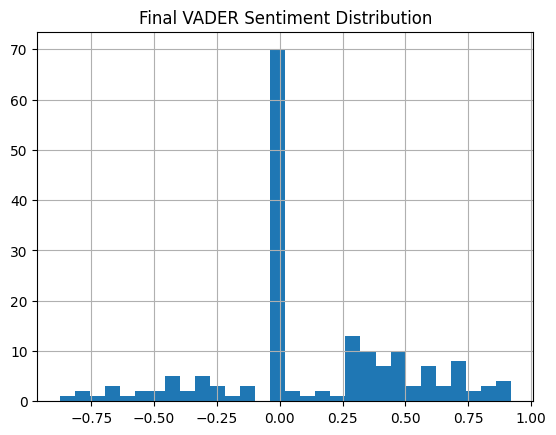

In [31]:
# get an idea for bin division
sentiment_subset["compound"].hist(bins=30)
plt.title("Final VADER Sentiment Distribution")
plt.show();

In [32]:
# use quantile bin divisions (33% and 66%) bc of wonky distribution
sentiment_subset["predicted"] = pd.qcut(sentiment_subset["compound"], q=3, labels=["neg", "neu", "pos"])

In [33]:
# add manually created list as a column "actual"
sentiment_subset["actual"] = sentiment_list
sentiment_subset.head()

,dialogue_line,neg,neu,pos,compound,predicted,actual
8961,"You know, I think I want to write a song about...",0.000,0.902,0.098,0.0772,neu,neu
8962,Oh yeah.,0.000,0.312,0.688,0.2960,neu,pos
8963,"Yeah. Oh, except one of the strings on my guit...",0.139,0.762,0.099,-0.2263,neg,neg
8964,How long you been waitin' to say that?,0.000,1.000,0.000,0.0000,neg,neu
8965,About 20 minutes. CLOSING CREDITS,0.000,0.553,0.447,0.4995,pos,neu


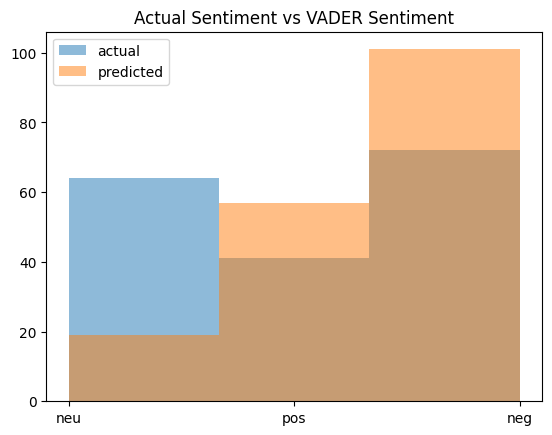

In [34]:
# plot both historgrams to see how the model performed
plt.hist(sentiment_subset['actual'], bins=3, alpha=0.5, label='actual')
plt.hist(sentiment_subset['predicted'], bins=3, alpha=0.5, label='predicted')
plt.title("Actual Sentiment vs VADER Sentiment")
plt.legend()
plt.show();

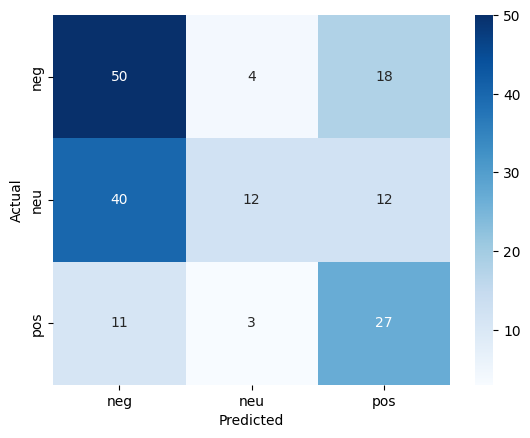

In [35]:
# confusion matrix
sent_cm = pd.crosstab(sentiment_subset["actual"], sentiment_subset["predicted"])
sns.heatmap(sent_cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [36]:
print(classification_report(sentiment_subset["actual"], sentiment_subset["predicted"]))

              precision    recall  f1-score   support

         neg       0.50      0.69      0.58        72
         neu       0.63      0.19      0.29        64
         pos       0.47      0.66      0.55        41

    accuracy                           0.50       177
   macro avg       0.53      0.51      0.47       177
weighted avg       0.54      0.50      0.47       177



#### Sentiment results

- **NEG:** The high recall for negative indicates that many TNs are captured (50), but half of the predicted negative are actually not negative (low precision, 40+11).
- **NEU:** The model rarely predicts "neutral" correctly (low recall), but when it does, it's usually correct (higher precision).
- **POS:** Similar to negative scores, with moderate recall and precision.

Overall low accuracy and F1-scores.

### Humor evaluation

In [37]:
print(f"{humor_subset.shape[0] / df_humor.shape[0]:.4f}% of the total dialogue lines were checked for sentiment.")

0.0033% of the total dialogue lines were checked for sentiment.


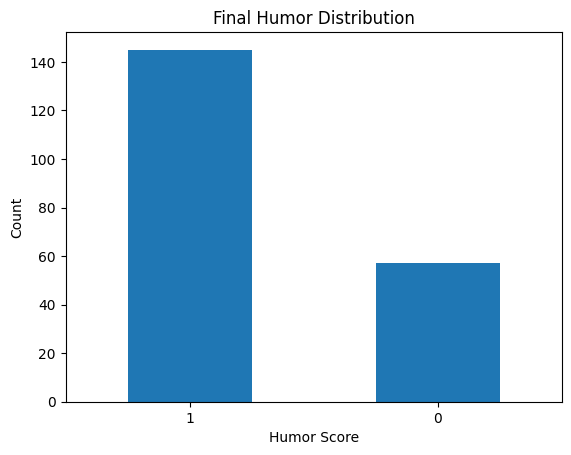

In [38]:
# get an idea for number of funny vs unfunny lines
humor_subset["humor"].value_counts().plot(kind="bar", xlabel="Humor Score", ylabel="Count", rot=0)
plt.title("Final Humor Distribution")
plt.show();

In [39]:
# add manually created list as a column "actual"
humor_subset["actual"] = humor_list
humor_subset.rename(columns={"humor": "predicted"}, inplace=True)
humor_subset.head()

,dialogue_line,predicted,actual
8852,Thanks for letting me tag along tonight you guys.,0,0
8853,Forget about it.,0,0
8854,How you doin there squirmy?,1,0
8855,I'm hangin in. . . and a little out.,1,1
8856,"So, assistant to the director. That's a really...",1,0


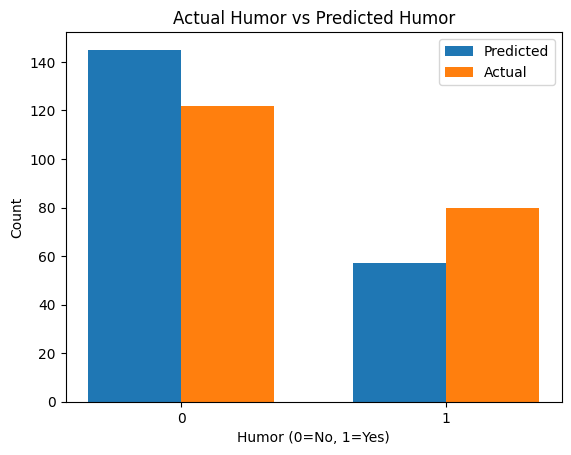

In [40]:
humor_pred = humor_subset["predicted"].value_counts()
humor_act = humor_subset["actual"].value_counts()

# making labels so there's an x-axis to pass
labels = [0, 1] 
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, humor_pred, width, label='Predicted')
plt.bar(x + width/2, humor_act, width, label='Actual')

plt.xticks(x, labels)
plt.xlabel('Humor (0=No, 1=Yes)')
plt.ylabel('Count')
plt.title('Actual Humor vs Predicted Humor')
plt.legend()

plt.show();

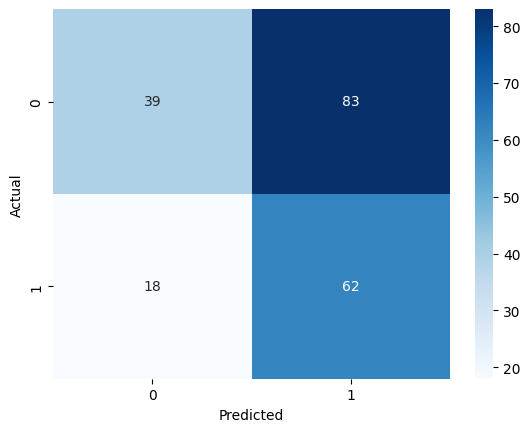

In [41]:
# confusion matrix
humor_cm = pd.crosstab(humor_subset["actual"], humor_subset["predicted"])
sns.heatmap(humor_cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [42]:
print(classification_report(humor_subset["actual"], humor_subset["predicted"]))

              precision    recall  f1-score   support

           0       0.68      0.32      0.44       122
           1       0.43      0.78      0.55        80

    accuracy                           0.50       202
   macro avg       0.56      0.55      0.49       202
weighted avg       0.58      0.50      0.48       202



#### Humor results

- **0: No humor:** Fairly good precision, but low recall, meaning it's missing many non-humorous lines -> Many FNs.
- **1: Humor:** High recall but low precision, meaning non-humorous lines are catergorized as humorous -> Many FPs

Overall low accuracy, only half of the predictions are correct.

### Emotion evaluation

In [43]:
print(f"{emotion_subset.shape[0] / df_emotion.shape[0]:.4f}% of the total dialogue lines were checked for sentiment.")

0.0036% of the total dialogue lines were checked for sentiment.


In [44]:
# Get dominant emotion from subset
emotion_cols = ["anger","disgust","fear","joy","neutral","sadness","surprise"]
emotion_subset["predicted"] = emotion_subset[emotion_cols].idxmax(axis=1)

In [45]:
# add manually created list as a column "actual"
emotion_subset["actual"] = emotion_list
emotion_subset.head()

,dialogue_line,anger,disgust,fear,joy,neutral,sadness,surprise,predicted,actual
8821,"OK, got the music, got the dinner. Oh and chec...",0.001563,0.001929,0.000461,0.046666,0.947151,0.000992,0.001239,neutral,neutral
8822,Oooh.,0.000975,0.003676,0.018050,0.373363,0.045448,0.004796,0.553693,surprise,joy
8823,With mealworms.,0.001764,0.042820,0.000690,0.039970,0.908077,0.002868,0.003811,neutral,neutral
8824,"Yaaahhh. Ahhh, candles. What'dya thinks gonna ...",0.003847,0.001801,0.015112,0.662566,0.304603,0.003960,0.008111,joy,disgust
8825,"Hello. Oh hi, are you on your way ove-. Oh. No...",0.004312,0.002355,0.024822,0.006356,0.954485,0.005964,0.001706,neutral,sadness


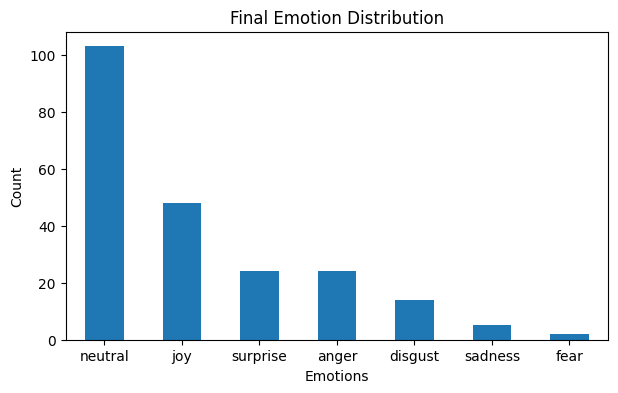

In [46]:
# get frequency of each emotion
emotion_subset["predicted"].value_counts().plot(kind="bar", xlabel="Emotions", ylabel="Count", rot=0, figsize=(7,4))
plt.title("Final Emotion Distribution")
plt.show();

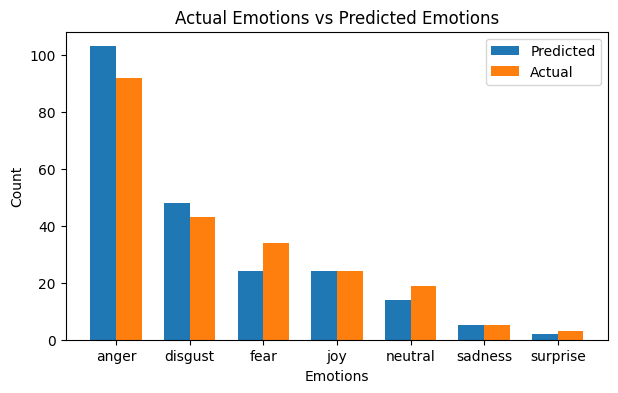

In [47]:
emotion_pred = emotion_subset["predicted"].value_counts()
emotion_act = emotion_subset["actual"].value_counts()

# making an x-axis to pass
x2 = np.arange(len(emotion_cols))

plt.figure(figsize=(7, 4))
plt.bar(x2 - width/2, emotion_pred, width, label='Predicted')
plt.bar(x2 + width/2, emotion_act, width, label='Actual')

plt.xticks(x2, emotion_cols)
plt.xlabel('Emotions')
plt.ylabel('Count')
plt.title('Actual Emotions vs Predicted Emotions')
plt.legend()

plt.show();

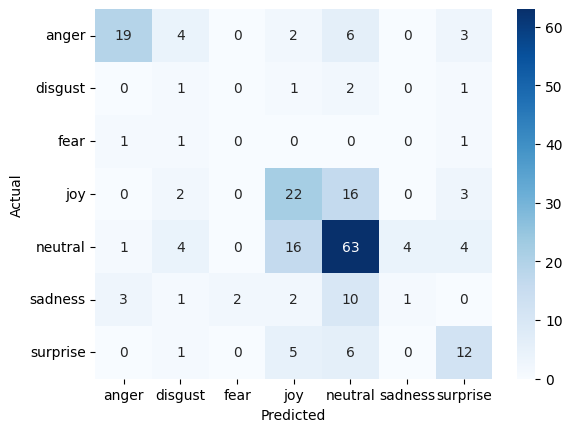

In [48]:
# confusion matrix
emotion_cm = pd.crosstab(emotion_subset["actual"], emotion_subset["predicted"])
sns.heatmap(emotion_cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [49]:
print(classification_report(emotion_subset["actual"], emotion_subset["predicted"]))

              precision    recall  f1-score   support

       anger       0.79      0.56      0.66        34
     disgust       0.07      0.20      0.11         5
        fear       0.00      0.00      0.00         3
         joy       0.46      0.51      0.48        43
     neutral       0.61      0.68      0.65        92
     sadness       0.20      0.05      0.08        19
    surprise       0.50      0.50      0.50        24

    accuracy                           0.54       220
   macro avg       0.38      0.36      0.35       220
weighted avg       0.54      0.54      0.53       220



#### Emotions results

- **Fear, Sadness, Disgust, Surprise:** Support too low for a valuable interpretation. They are rare emotions in the show.
- **Anger:** High precision with moderate recall.
- **Joy:** Moderate performance.
- **Neutral:** Model's best category.

Moderate accuracy, though model is biased towards more common emotions.